In [4]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [7]:
def plot_original_graph(distances):
    """Grafica la red completa con los pesos de las aristas."""
    G = nx.from_numpy_array(distances)
    pos = nx.spring_layout(G, seed=42)  # Layout fijo para consistencia
    
    plt.figure(figsize=(10, 7))
    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
    # Dibujar etiquetas de nodos
    nx.draw_networkx_labels(G, pos)
    # Dibujar aristas con transparencia (para no saturar si son muchos nodos)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    
    # Dibujar pesos (solo si no son demasiados nodos para que sea legible)
    if len(distances) <= 10:
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    
    plt.title("1) Gráfica Original (Todas las conexiones)")
    plt.show()
    return pos # Retornamos la posición para usarla en la siguiente función

def plot_solution_path(distances, path, pos):
    """Grafica la solución encontrada resaltando el camino sobre la gráfica original."""
    G = nx.from_numpy_array(distances)
    
    # Creamos una lista de tuplas para las aristas del camino solución
    solution_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    
    plt.figure(figsize=(10, 7))
    # Dibujamos todos los nodos
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
    nx.draw_networkx_labels(G, pos)
    
    # Dibujamos todas las aristas muy tenues
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray')
    
    # Resaltamos el camino de la solución en rojo y más grueso
    nx.draw_networkx_edges(G, pos, edgelist=solution_edges, 
                           edge_color='red', width=2.5, arrowstyle='->', arrowsize=20)
    
    plt.title(f"2) Solución ACO (Distancia: {best_distance:.2f})")
    plt.show()



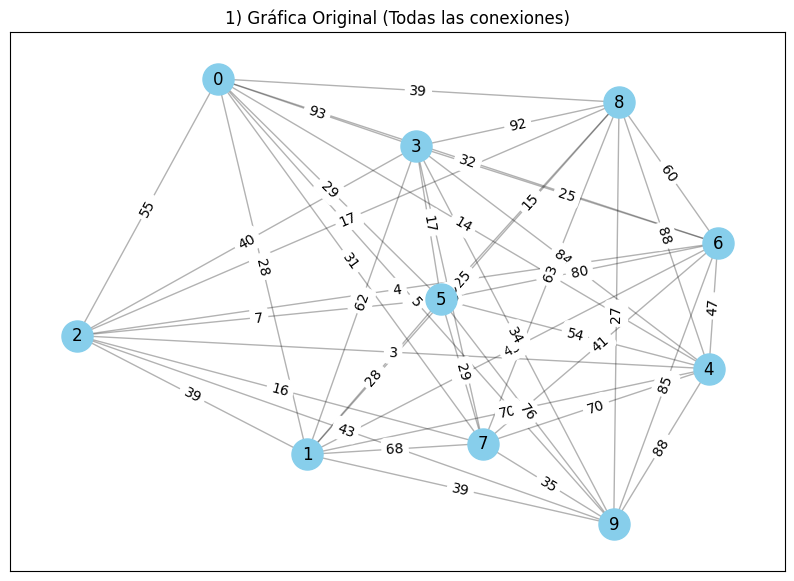

In [8]:
# --- EJECUCIÓN DEL SCRIPT ---

num_nodes = 10 # Reducido a 10 para mejor visualización de etiquetas
distances = np.random.randint(1, 100, size=(num_nodes, num_nodes))
np.fill_diagonal(distances, 0)

# Llamada a las nuevas funciones
posiciones = plot_original_graph(distances)

/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_34886/403381070.py:39: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=solution_edges,
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_34886/403381070.py:39: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edgelist=solution_edges,


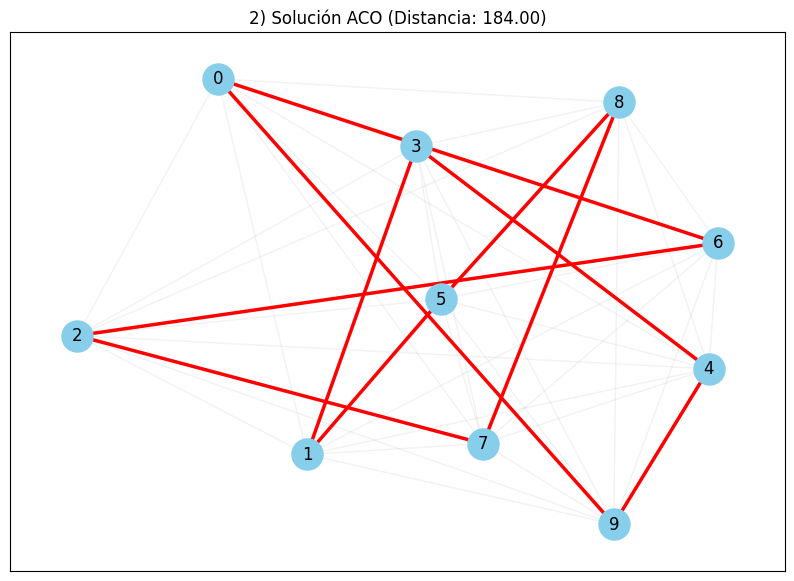

In [9]:
graph = Graph(distances)
aco = ACO(graph, num_ants=15, num_iterations=50)
best_path, best_distance = aco.run()

plot_solution_path(distances, best_path, posiciones)

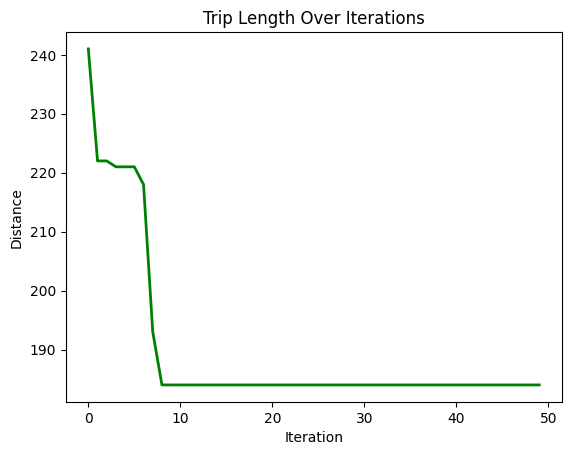

In [10]:
# Plotting the distance over iterations (second plot) - Shows how the path length improves over time
def plot_distance_over_iterations(best_distance_history):
    # Plot the best distance found in each iteration (should decrease over time)
    plt.plot(best_distance_history, color='green', linewidth=2)
    plt.title("Trip Length Over Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("Distance")
    plt.show()

plot_distance_over_iterations(aco.best_distance_history)